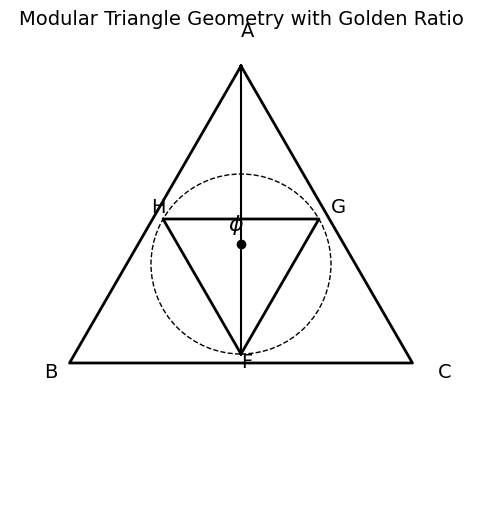

In [1]:
import matplotlib.pyplot as plt
import numpy as np

def equilateral_triangle(center, radius, rotation=0):
    angles = np.deg2rad(np.array([90, 210, 330]) + rotation)
    return np.array([
        center + radius * np.array([np.cos(a), np.sin(a)])
        for a in angles
    ])

# Setup
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal')
ax.axis('off')

# Large triangle ABC
center = np.array([0, 0])
R_outer = 3
ABC = equilateral_triangle(center, R_outer)
A, B, C = ABC

# Inner triangle FGH (smaller, inscribed)
R_inner = R_outer / 2.2  # Adjust this ratio to simulate "circumcircle = incircle"
FGH = equilateral_triangle(center, R_inner, rotation=180)
F, G, H = FGH

# Draw triangles
triangle = lambda pts: plt.plot(*zip(*(pts.tolist() + [pts[0]])), 'k', lw=2)
triangle(ABC)
triangle(FGH)

# Draw dashed circle (shared circle)
circle = plt.Circle(center, R_inner, edgecolor='k', linestyle='--', facecolor='none')
ax.add_patch(circle)

# Draw golden ratio mark and label
mid_AF = A + (F - A) / (1 + 1/1.618)  # golden ratio division of AF
plt.plot(*zip(A, F), 'k')
plt.plot(*mid_AF, marker='o', color='black')
ax.text(*(mid_AF + np.array([-0.2, 0.2])), r'$\phi$', fontsize=16)

# Labels
labels = {'A': A, 'B': B, 'C': C, 'F': F, 'G': G, 'H': H}
for name, point in labels.items():
    ax.text(*(point + 0.15 * (point - center)), name, fontsize=14)

plt.xlim(-3.5, 3.5)
plt.ylim(-3.5, 3.5)
plt.title("Modular Triangle Geometry with Golden Ratio", fontsize=14)
plt.show()